In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [8]:
FILE = 'superstore.xlsx'

orders = pd.read_excel(FILE, sheet_name='Orders')
people = pd.read_excel(FILE, sheet_name='People')
returns = pd.read_excel(FILE, sheet_name='Returns')

orders.shape, people.shape, returns.shape

((10194, 21), (4, 2), (296, 2))

In [9]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


# Initial Observations

In [11]:
orders.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [12]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [13]:
orders.describe() 

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [14]:
orders.describe(include='object')

C:\Users\shukl\AppData\Local\Temp\ipykernel_6196\2593384548.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  orders.describe(include='object')


,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,5111,4,804,800,3,2,542,59,654,4,1862,3,17,1849
top,US-2026-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,FUR-FU-10004270,Office Supplies,Binders,Staples
freq,14,6120,41,41,5281,9994,915,2001,263,3253,20,6128,1548,50


# Missing Values

In [22]:
orders.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

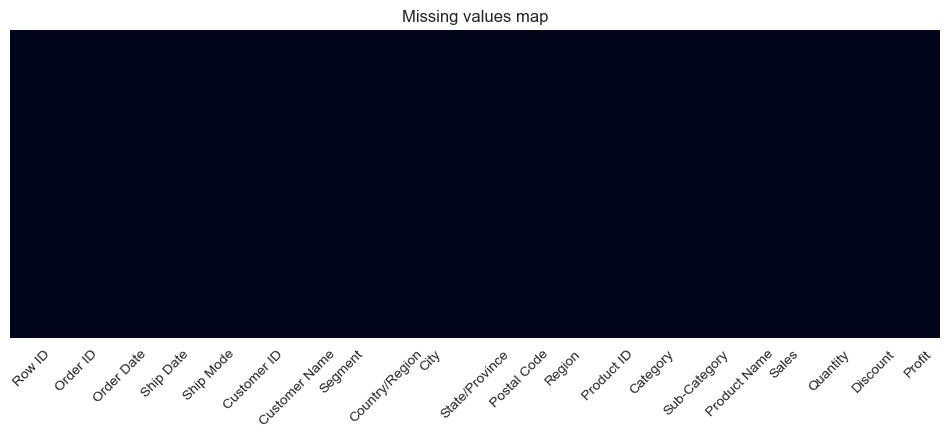

In [20]:
orders.isnull().sum()

plt.figure(figsize=(12,4))
sns.heatmap(orders.isnull(), cbar=False, yticklabels=False)
plt.xticks(rotation=45)
plt.title('Missing values map')
plt.show()

# Duplicate rows

In [77]:
for col in orders[orders.duplicated()].columns:
    print(col)
print("-" * 100)
print('Number of duplicate values are:',orders.duplicated().sum())

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country/Region
City
State/Province
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit
Order Year
Order Month
Order Month Name
Shipping Delay (days)
----------------------------------------------------------------------------------------------------
Number of duplicate values are: 0


# Explore categorical columns

In [47]:
cat_cols = ['Ship Mode', 'Segment', 'Country/Region', 'Region', 'Category', 'Sub-Category']

for col in cat_cols:
    print(col, ':', 'Unique Values ->',orders[col].nunique(), '| Length ->',len(orders[col].unique()))
    print(list(orders[col].unique()))
    print()

Ship Mode : Unique Values -> 4 | Length -> 4
['Standard Class', 'First Class', 'Second Class', 'Same Day']

Segment : Unique Values -> 3 | Length -> 3
['Consumer', 'Home Office', 'Corporate']

Country/Region : Unique Values -> 2 | Length -> 2
['United States', 'Canada']

Region : Unique Values -> 4 | Length -> 4
['Central', 'East', 'South', 'West']

Category : Unique Values -> 3 | Length -> 3
['Office Supplies', 'Furniture', 'Technology']

Sub-Category : Unique Values -> 17 | Length -> 17
['Paper', 'Binders', 'Labels', 'Storage', 'Art', 'Chairs', 'Fasteners', 'Phones', 'Furnishings', 'Accessories', 'Bookcases', 'Envelopes', 'Appliances', 'Tables', 'Supplies', 'Machines', 'Copiers']



In [91]:
cat_cols = ['Ship Mode', 'Segment', 'Country/Region', 'Region', 'Category', 'Sub-Category']

for col in cat_cols:
    orders[col] = orders[col].astype('category')
    
orders[cat_cols].dtypes

Ship Mode         category
Segment           category
Country/Region    category
Region            category
Category          category
Sub-Category      category
dtype: object

# Date range and derived time features

In [61]:
orders['Order Date'].min(), orders['Order Date'].max()

(Timestamp('2023-01-03 00:00:00'), Timestamp('2026-12-30 00:00:00'))

In [64]:
orders['Order Year'] = orders['Order Date'].dt.year
orders['Order Year'].head()

0    2023
1    2023
2    2023
3    2023
4    2023
Name: Order Year, dtype: int32

In [68]:
orders['Order Year'].unique()

array([2023, 2024, 2025, 2026], dtype=int32)

In [65]:
orders['Order Month Name'] = orders['Order Date'].dt.month_name()
orders['Order Month Name'].head()

0    January
1    January
2    January
3    January
4    January
Name: Order Month Name, dtype: str

In [69]:
orders['Order Month Name'].unique()

<ArrowStringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [66]:
orders['Shipping Delay (days)'] = (orders['Ship Date'] - orders['Order Date']).dt.days
orders['Shipping Delay (days)'].head()

0    4
1    4
2    4
3    4
4    7
Name: Shipping Delay (days), dtype: int64

# Non-Graphical Analysis

In [96]:
cat_cols = ['Ship Mode', 'Segment', 'Country/Region', 'Region', 'Category', 'Sub-Category']

for col in cat_cols:
    print(orders[col].value_counts())
    print()
    print("-" * 100)
    print()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------

Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------

Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------

Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

----------------------------------------------------------------------------

# Univariate analysis (numeric columns)

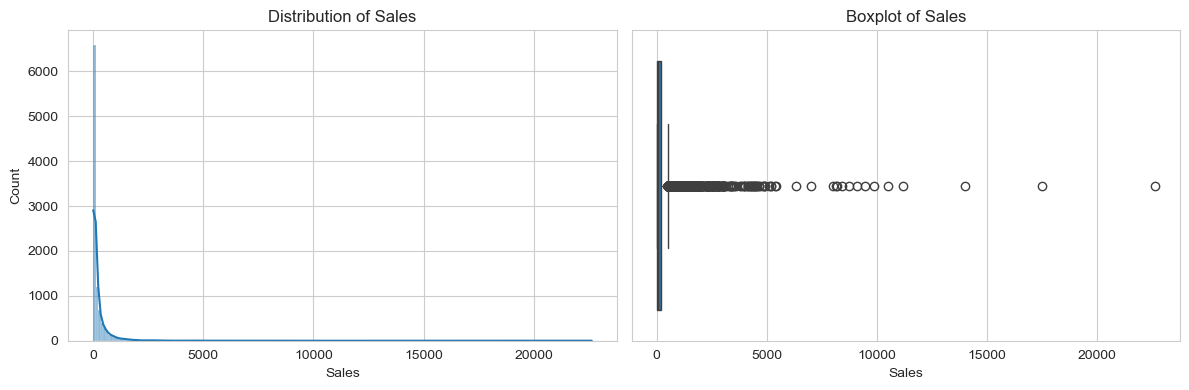

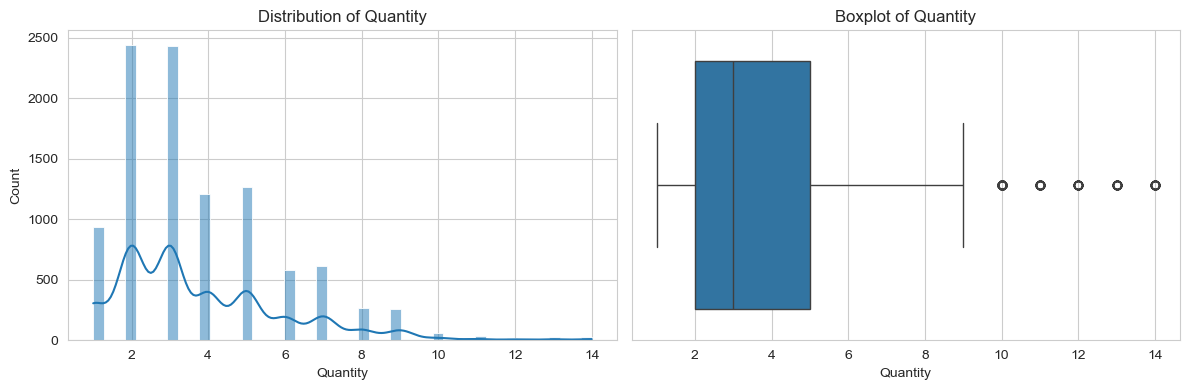

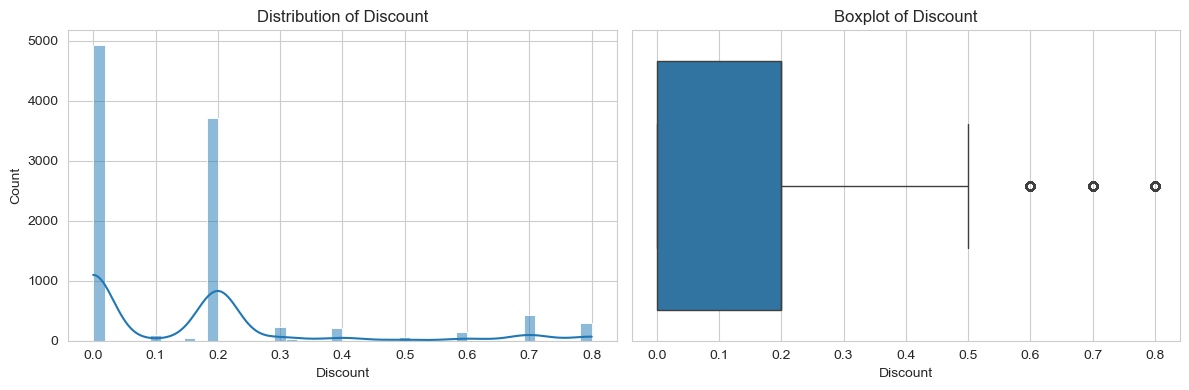

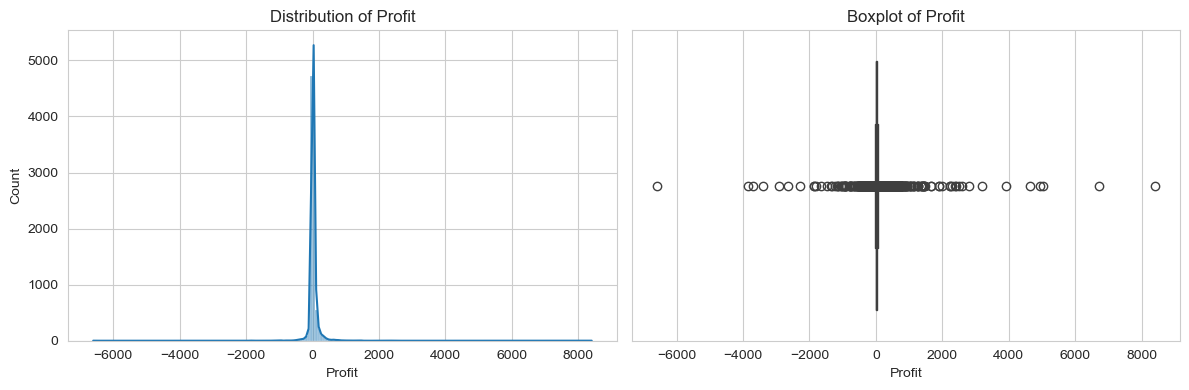

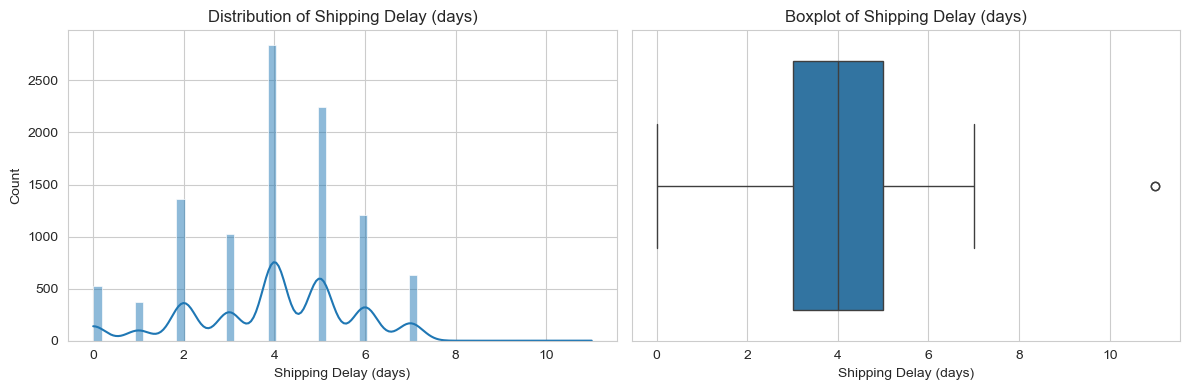

In [119]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Delay (days)']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(orders[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=orders[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()
    print("\n")

# Outlier detection (IQR method)

In [99]:
for col in num_cols:
    Q1 = orders[col].quantile(0.25)
    Q3 = orders[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = orders[(orders[col] < lower) | (orders[col] > upper)].shape[0]
    print(f'{col}: {n_out} outliers ({n_out/len(orders)*100:.1f}%)')

Sales: 1183 outliers (11.6%)
Quantity: 175 outliers (1.7%)
Discount: 874 outliers (8.6%)
Profit: 1913 outliers (18.8%)
Shipping Delay (days): 2 outliers (0.0%)


# Univariate analysis (categorical columns)

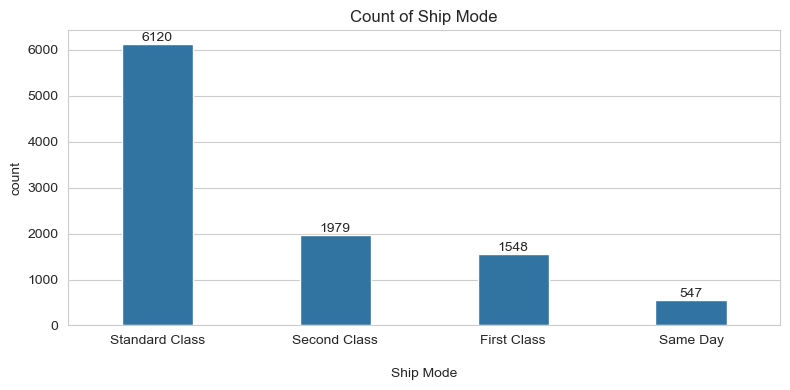

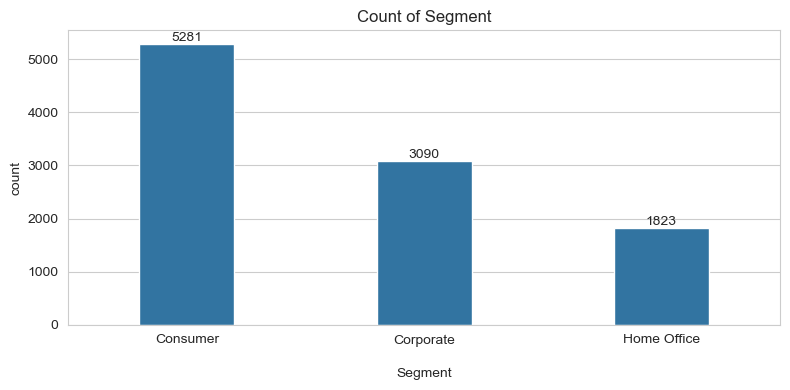

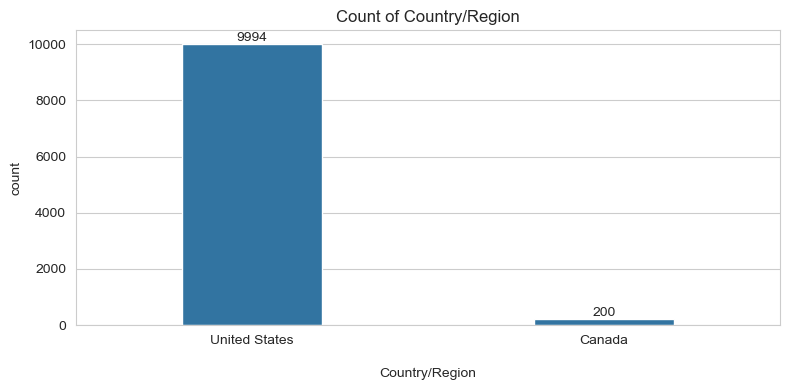

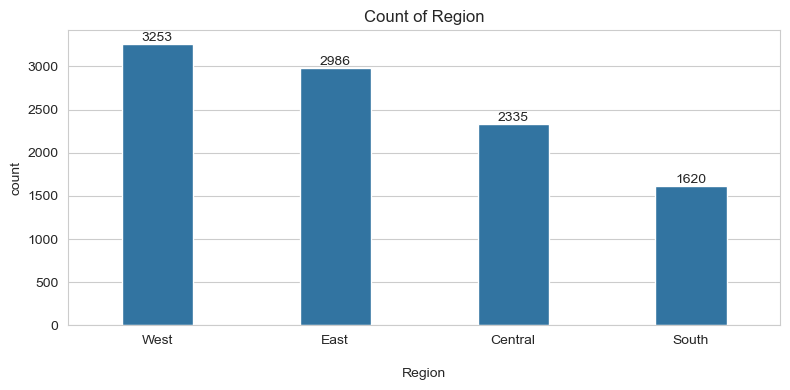

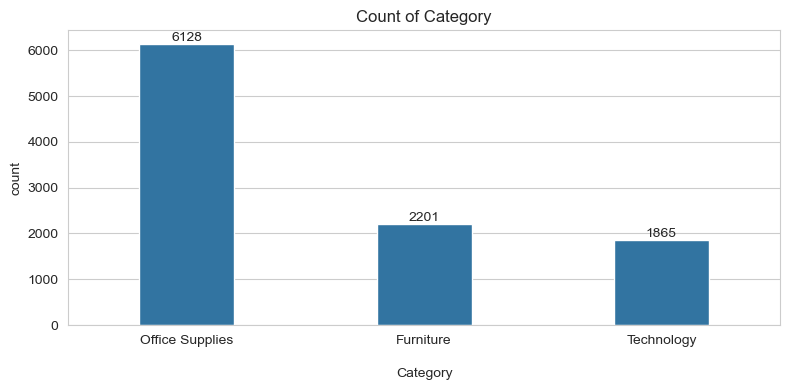

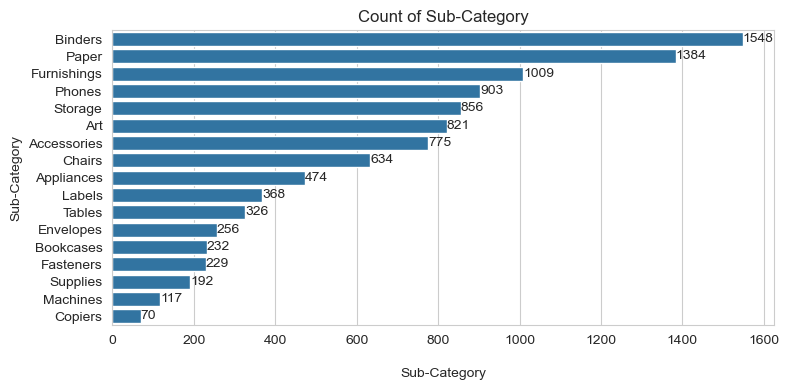

In [125]:
cat_cols = ['Ship Mode', 'Segment', 'Country/Region', 'Region', 'Category', 'Sub-Category']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    order_vals = orders[col].value_counts().index
    
    if orders[col].nunique() <= 4:
        ax = sns.countplot(data=orders, x=col, order=order_vals, width=0.4)   # column chart
        ax.bar_label(ax.containers[0])
        # plt.xticks(rotation=45)
    else:
        ax = sns.countplot(data=orders, y=col, order=order_vals)   # bar chart
        ax.bar_label(ax.containers[0])
    plt.title(f'Count of {col}')
    plt.xlabel(col, labelpad=15)
    plt.tight_layout()
    plt.show()
    print("\n")

# Sales & Profit by Category / Sub-Category

In [126]:
cat_summary = orders.groupby('Category')[['Sales','Profit','Quantity']].sum().round(2).sort_values('Sales', ascending=False)
cat_summary

,Sales,Profit,Quantity
Category,,,
Technology,839893.28,146543.38,7017
Furniture,754747.76,19730.00,8369
Office Supplies,731893.31,126023.44,23268


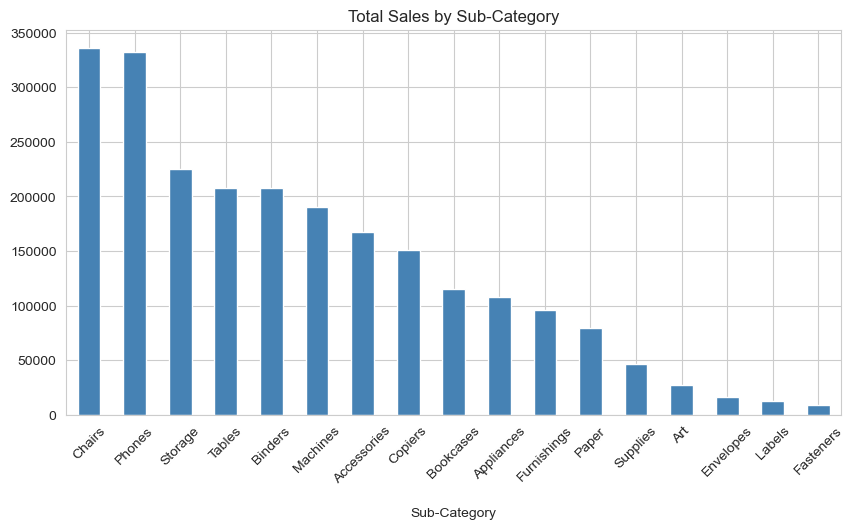

In [149]:
sub_summary = orders.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

plt.figure(figsize=(10,5))
sub_summary['Sales'].plot(kind='bar', color='steelblue')
plt.title('Total Sales by Sub-Category')
plt.xticks(rotation=45)
plt.xlabel(col, labelpad=15)
plt.show()

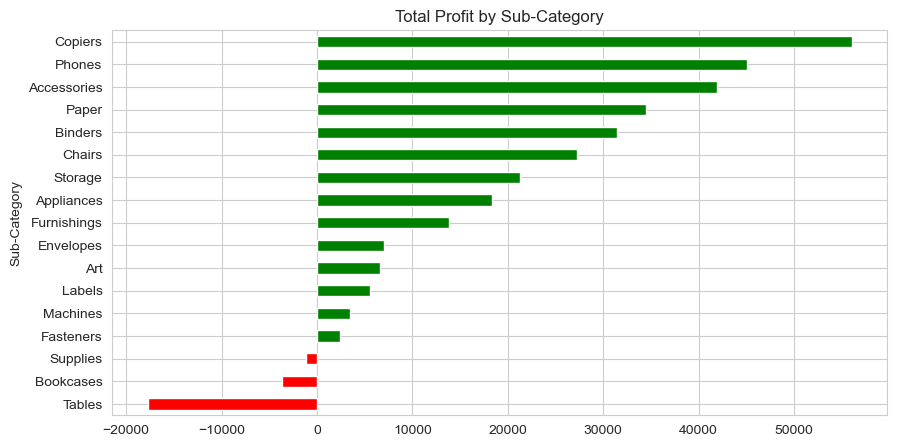

In [135]:
plt.figure(figsize=(10,5))
sub_summary['Profit'].sort_values().plot(
    kind='barh',
    color=sub_summary['Profit'].sort_values().apply(lambda x: 'green' if x > 0 else 'red')
)
plt.title('Total Profit by Sub-Category')
plt.show()

# Sales & Profit by Region / Segment

In [139]:
region_summary = orders.groupby('Region')[['Sales','Profit']].sum().round(2).sort_values('Sales', ascending=False)
region_summary

,Sales,Profit
Region,,
West,739813.61,110798.82
East,691828.17,94883.26
Central,503170.67,39865.31
South,391721.90,46749.43


In [140]:
segment_summary = orders.groupby('Segment')[['Sales','Profit']].sum().round(2).sort_values('Sales', ascending=False)
segment_summary

,Sales,Profit
Segment,,
Consumer,1170659.79,136371.45
Corporate,715806.13,94249.64
Home Office,440068.43,61675.73


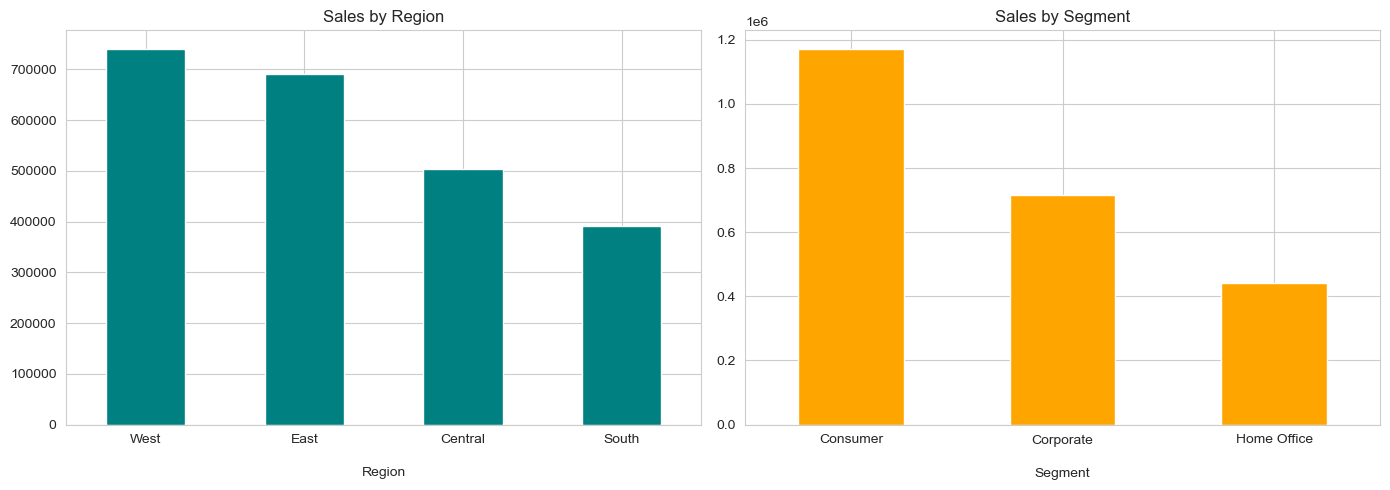

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

region_summary['Sales'].plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Sales by Region')
axes[0].set_xlabel('Region', labelpad=15)
axes[0].tick_params(axis='x', rotation=0)

segment_summary['Sales'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sales by Segment')
axes[1].set_xlabel('Segment', labelpad=15)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Monthly sales & profit trend

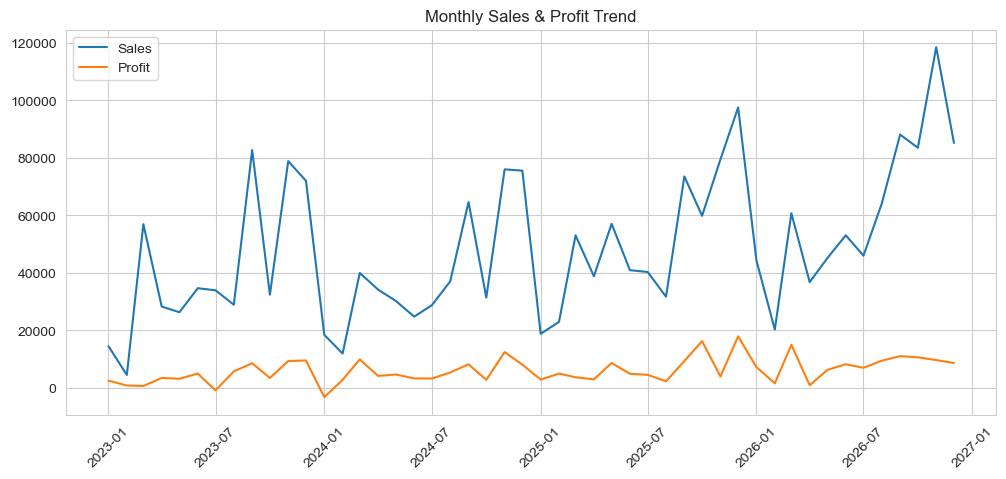

In [156]:
monthly = orders.groupby(orders['Order Date'].dt.to_period('M'))[['Sales','Profit']].sum()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly['Sales'], label='Sales')
plt.plot(monthly.index, monthly['Profit'], label='Profit')
plt.legend()
plt.title('Monthly Sales & Profit Trend')
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap

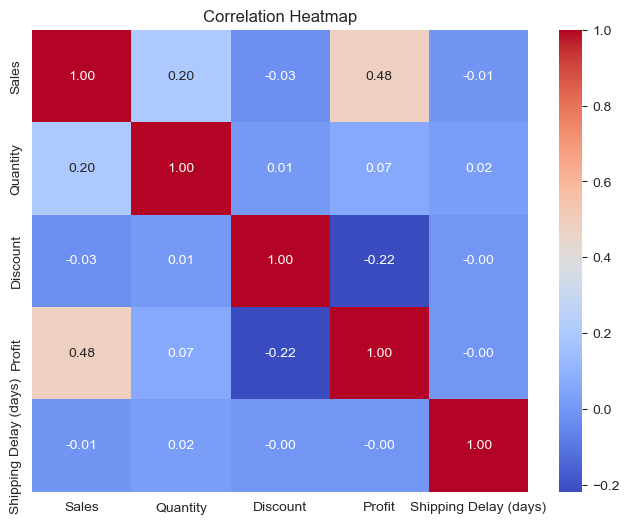

In [157]:
plt.figure(figsize=(8,6))
corr = orders[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Discount vs Profit (bivariate)

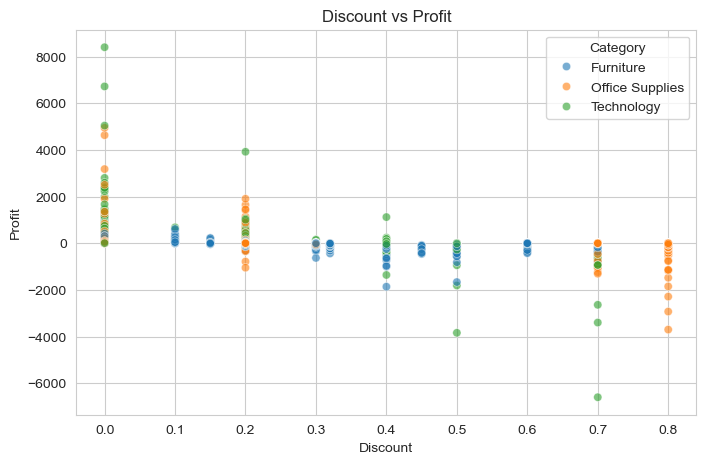

In [158]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=orders, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit')
plt.show()

# Top customers and products

In [162]:
orders.groupby('Customer Name')['Sales'].sum().round().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.0
Tamara Chand          19052.0
Raymond Buch          15117.0
Tom Ashbrook          14596.0
Adrian Barton         14474.0
Ken Lonsdale          14175.0
Sanjit Chand          14142.0
Hunter Lopez          12873.0
Sanjit Engle          12209.0
Christopher Conant    12129.0
Name: Sales, dtype: float64

In [161]:
orders.groupby('Product Name')['Sales'].sum().round().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61600.0
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.0
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.0
HON 5400 Series Task Chairs for Big and Tall                                   21871.0
GBC DocuBind TL300 Electric Binding System                                     19823.0
GBC Ibimaster 500 Manual ProClick Binding System                               19024.0
Hewlett Packard LaserJet 3310 Copier                                           18840.0
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18375.0
GBC DocuBind P400 Electric Binding System                                      17965.0
High Speed Automatic Electric Letter Opener                                    17030.0
Name: Sales, dtype: float64

# Merge with People sheet

In [163]:
orders_people = orders.merge(people, on='Region', how='left')
orders_people[['Region', 'Regional Manager']].drop_duplicates()

,Region,Regional Manager
0,Central,Roxanne Rodriguez
4,East,Chuck Magee
5,South,Fred Suzuki
11,West,Sadie Pawthorne


# Merge with Returns sheet

In [164]:
orders_returns = orders.merge(returns, on='Order ID', how='left')
orders_returns['Returned'] = orders_returns['Returned'].fillna('No')

return_rate_by_cat = orders_returns.groupby('Category')['Returned'].apply(lambda x: (x == 'Yes').mean() * 100)
return_rate_by_cat

Category
Furniture          7.769196
Office Supplies    7.718668
Technology         8.364611
Name: Returned, dtype: float64

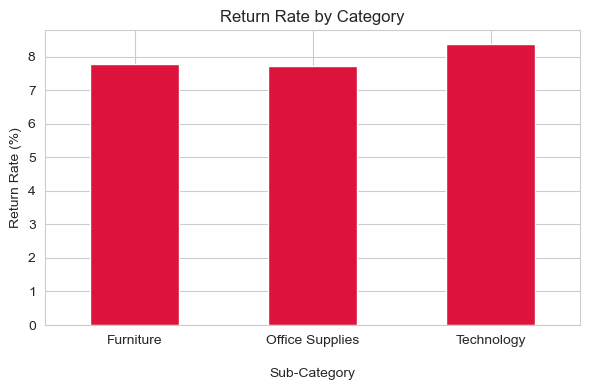

In [171]:
plt.figure(figsize=(6,4))
return_rate_by_cat.plot(kind='bar', color='crimson')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Category')
plt.xticks(rotation=0)
plt.xlabel(col, labelpad=15)
plt.tight_layout()
plt.show()

# Summary table

In [172]:
summary = pd.DataFrame({
    'dtype': orders.dtypes,
    'missing_%': orders.isnull().mean() * 100,
    'unique_values': orders.nunique()
})
summary

,dtype,missing_%,unique_values
Row ID,int64,0.0,10194
Order ID,str,0.0,5111
Order Date,datetime64[us],0.0,1242
Ship Date,datetime64[us],0.0,1338
Ship Mode,category,0.0,4
Customer ID,str,0.0,804
Customer Name,str,0.0,800
Segment,category,0.0,3
Country/Region,category,0.0,2
City,str,0.0,542


# Connect to PostgresSQL

In [173]:
!pip install sqlalchemy psycopg2-binary

In [176]:
from sqlalchemy import create_engine

username = 'postgres'
password = '1234'
host = 'localhost'
port = '5432'
database = 'superstore'

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

In [177]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    print(result.fetchone())

('PostgreSQL 18.6 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit',)


In [178]:
orders.to_sql('orders', engine, if_exists='replace', index=False)

194

In [179]:
people.to_sql('people', engine, if_exists='replace', index=False)
returns.to_sql('returns', engine, if_exists='replace', index=False)

296

In [180]:
query = "SELECT * FROM orders LIMIT 5;"
pd.read_sql(query, engine)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Shipping Delay (days)
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,January,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January,7
